In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons, make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

### What is Backpropagation?

**Backpropagation** is the algorithm that teaches neural networks by:

| Step | Action |
|------|--------|
| **Forward Pass** | Make a prediction |
| **Calculate Error** | How wrong was the prediction? |
| **Backward Pass** | Send the error backwards through the network |
| **Update Weights** | Adjust weights to reduce the error |

```mermaid
graph LR
    A["1. Forward Pass<br>Make a Prediction"] --> B["2. Calculate Error<br>How wrong?"]
    B --> C["3. Backward Pass<br>Send error backwards"]
    C --> D["4. Update Weights<br>Reduce error"]
    D --> A
```

#### Step-by-Step

| Step | What Happens | Formula |
|------|--------------|---------|
| **1. Forward Pass** | Inputs pass through the network to produce an output | $y = f(w \cdot x + b)$ |
| **2. Calculate Error** | Compare prediction to true label | $\text{Loss} = -\frac{1}{N} \sum [y_i \log(\hat{y}_i) + (1 - y_i) \log(1 - \hat{y}_i)]$ |
| **3. Backward Pass** | Compute how much each weight contributed to the error | $\frac{\partial L}{\partial w} = \dots$ (Chain rule) |
| **4. Update Weights** | Adjust weights in the direction that reduces error | $w = w - \alpha \cdot \frac{\partial L}{\partial w}$ |

#### The Chain Rule (The Math Behind Backpropagation)

Loss ← Output ← Hidden Layer 2 ← Hidden Layer 1 ← Input

$$
\frac{\partial L}{\partial w_1} = \frac{\partial L}{\partial \text{Output}} \times \frac{\partial \text{Output}}{\partial \text{Hidden2}} \times \frac{\partial \text{Hidden2}}{\partial \text{Hidden1}} \times \frac{\partial \text{Hidden1}}{\partial w_1}
$$


1. Predict (Forward)
2. Measure error (Loss)
3. Learn from error (Backward)
4. Improve weights (Update)



In [41]:
class NeuralNetwork:
    def __init__(self, input_size, hidden_size, output_size, learning_rate=0.1):
        self.learning_rate = learning_rate
        
        # Initialize weights and biases
        self.W1 = np.random.randn(input_size, hidden_size) * np.sqrt(2.0 / input_size)
        self.b1 = np.zeros((1, hidden_size))
        self.W2 = np.random.randn(hidden_size, output_size) * np.sqrt(2.0 / hidden_size)
        self.b2 = np.zeros((1, output_size))
        
        # Store history for visualization
        self.loss_history = []
        self.accuracy_history = []
    
    def sigmoid(self, z):
        """Sigmoid activation function"""
        return 1 / (1 + np.exp(-np.clip(z, -500, 500)))
    
    def sigmoid_derivative(self, z):
        """Derivative of sigmoid for backpropagation"""
        s = self.sigmoid(z)
        return s * (1 - s)
    
    def forward(self, X):
        """Forward pass through the network"""
        # Layer 1
        self.z1 = np.dot(X, self.W1) + self.b1
        self.a1 = self.sigmoid(self.z1)
        
        # Layer 2 (output)
        self.z2 = np.dot(self.a1, self.W2) + self.b2
        self.a2 = self.sigmoid(self.z2)
        
        return self.a2
    
    def compute_loss(self, y_true, y_pred):
        """Binary cross-entropy loss"""
        eps = 1e-15
        y_pred = np.clip(y_pred, eps, 1 - eps)
        return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))
    
    def backward(self, X, y_true, y_pred):
        """Backward pass - the heart of backpropagation!"""
        m = X.shape[0]  # Number of samples
        
        # ============================================
        # STEP 1: Compute error at output layer
        # ============================================
        # Derivative of loss w.r.t output
        # For binary cross-entropy with sigmoid: dL/dz2 = y_pred - y_true
        dL_dz2 = y_pred - y_true.reshape(-1, 1)
        
        # ============================================
        # STEP 2: Backpropagate to hidden layer
        # ============================================
        # dL/dW2 = (dL/dz2) * (dz2/dW2) = (dL/dz2) * a1.T
        dW2 = np.dot(self.a1.T, dL_dz2) / m
        db2 = np.sum(dL_dz2, axis=0, keepdims=True) / m
        
        # Backpropagate error to hidden layer
        # dL/da1 = (dL/dz2) * (dz2/da1) = dL_dz2 * W2.T
        dL_da1 = np.dot(dL_dz2, self.W2.T)
        
        # dL/dz1 = (dL/da1) * (da1/dz1) = dL_da1 * sigmoid_derivative(z1)
        dL_dz1 = dL_da1 * self.sigmoid_derivative(self.z1)
        
        # dL/dW1 = (dL/dz1) * (dz1/dW1) = dL_dz1 * X.T
        dW1 = np.dot(X.T, dL_dz1) / m
        db1 = np.sum(dL_dz1, axis=0, keepdims=True) / m
        
        # ============================================
        # STEP 3: Update weights (Gradient Descent)
        # ============================================
        self.W2 -= self.learning_rate * dW2
        self.b2 -= self.learning_rate * db2
        self.W1 -= self.learning_rate * dW1
        self.b1 -= self.learning_rate * db1
        
        return dL_dz2.mean()
    
    def fit(self, X, y, epochs=1000, verbose=True):
        """Train the neural network"""
        for epoch in range(epochs):
            # Forward pass
            y_pred = self.forward(X)
            
            # Compute loss
            loss = self.compute_loss(y, y_pred)
            self.loss_history.append(loss)
            
            # Backward pass (this is where the learning happens!)
            self.backward(X, y, y_pred)
            
            # Calculate accuracy
            y_pred_binary = (y_pred > 0.5).astype(int)
            acc = accuracy_score(y, y_pred_binary)
            self.accuracy_history.append(acc)
            
            if verbose and epoch % 200 == 0:
                print(f"Epoch {epoch}: Loss = {loss:.4f}, Accuracy = {acc:.4f}")
    
    def predict(self, X):
        """Predict class labels"""
        y_pred = self.forward(X)
        return (y_pred > 0.5).astype(int)
    
    def predict_proba(self, X):
        """Predict probabilities"""
        return self.forward(X)

In [42]:
# dataset with non-linear patterns
X, y = make_moons(n_samples=500, noise=0.2, random_state=42)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training: {len(X_train)} samples")
print(f"Test: {len(X_test)} samples")
print(f"Features: {X.shape[1]}")

# Create and train neural network
nn = NeuralNetwork(
    input_size=2,
    hidden_size=10,
    output_size=1,
    learning_rate=0.5
)

nn.fit(X_train, y_train, epochs=2000, verbose=True)

# Evaluate
y_pred = nn.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"\nTest Accuracy: {accuracy:.4f}")

Training: 400 samples
Test: 100 samples
Features: 2
Epoch 0: Loss = 0.7254, Accuracy = 0.5575
Epoch 200: Loss = 1.2947, Accuracy = 0.8625
Epoch 400: Loss = 1.4449, Accuracy = 0.8650
Epoch 600: Loss = 1.4746, Accuracy = 0.8650
Epoch 800: Loss = 1.4840, Accuracy = 0.8675
Epoch 1000: Loss = 1.4897, Accuracy = 0.8725
Epoch 1200: Loss = 1.4945, Accuracy = 0.8900
Epoch 1400: Loss = 1.5051, Accuracy = 0.9125
Epoch 1600: Loss = 1.5307, Accuracy = 0.9250
Epoch 1800: Loss = 1.5744, Accuracy = 0.9450

Test Accuracy: 0.9500


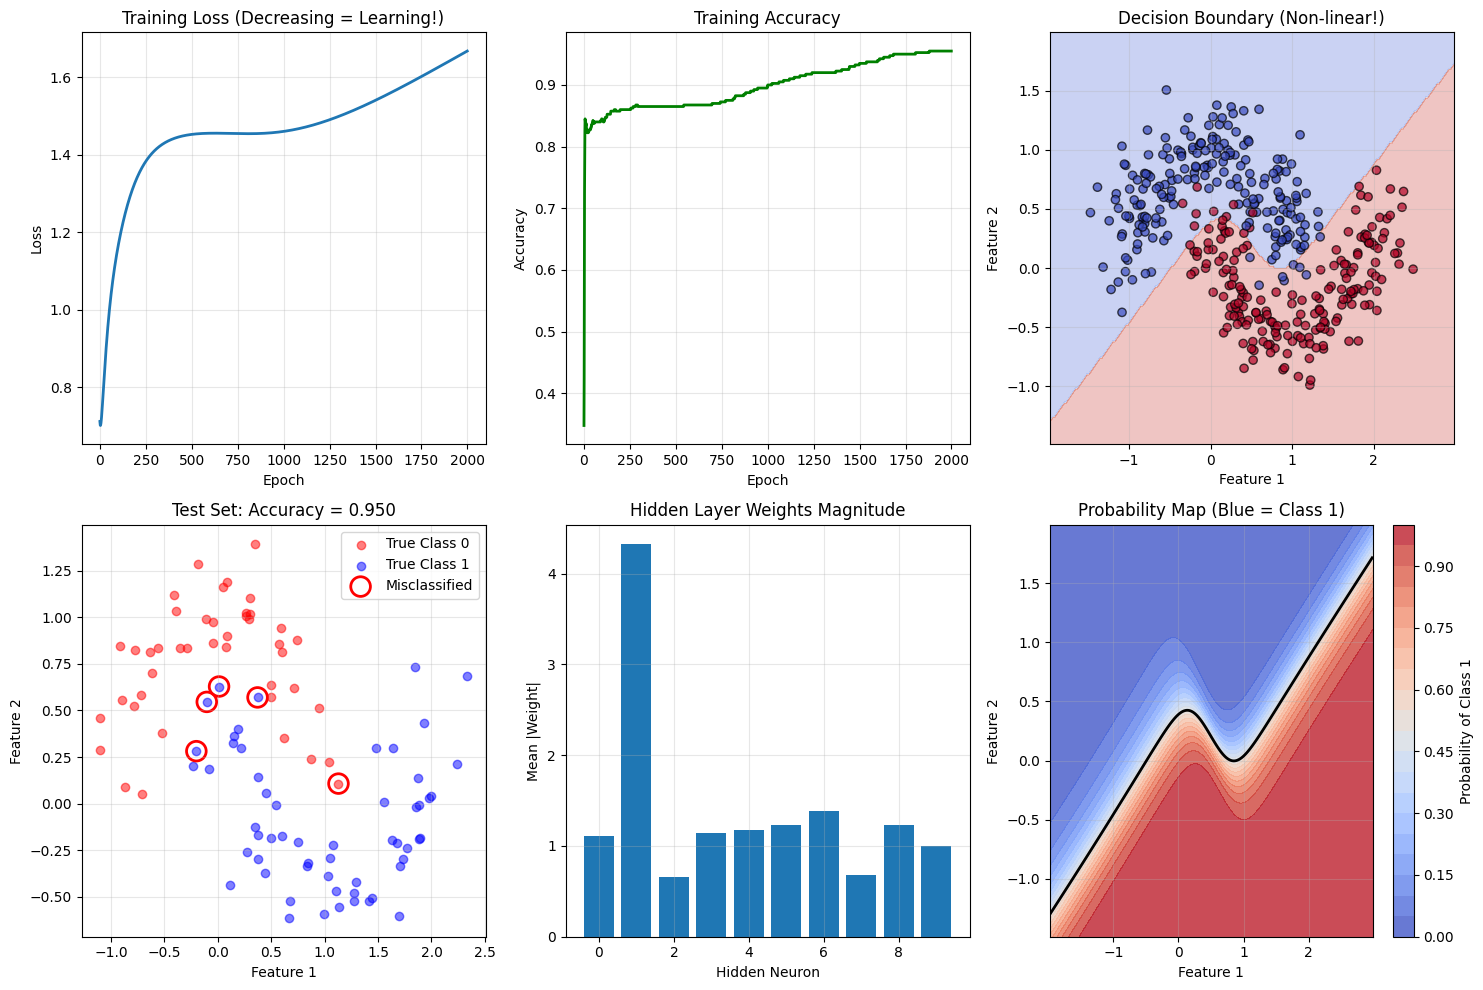

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Plot 1: Loss history
ax = axes[0, 0]
ax.plot(nn.loss_history, linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Training Loss (Decreasing = Learning!)')
ax.grid(True, alpha=0.3)

# Plot 2: Accuracy history
ax = axes[0, 1]
ax.plot(nn.accuracy_history, linewidth=2, color='green')
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy')
ax.set_title('Training Accuracy')
ax.grid(True, alpha=0.3)

# Plot 3: Decision boundary after training
ax = axes[0, 2]
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))
Z = nn.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)
ax.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
ax.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap='coolwarm', alpha=0.7, edgecolors='black')
ax.set_title('Decision Boundary (Non-linear!)')
ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
ax.grid(True, alpha=0.3)

# Plot 4: Test set predictions
ax = axes[1, 0]
for i, label in enumerate([0, 1]):
    mask = y_test == label
    ax.scatter(X_test[mask, 0], X_test[mask, 1],
               c=['red', 'blue'][i], label=f'True Class {i}', alpha=0.5)

# Highlight misclassifications
y_pred_test = nn.predict(X_test)
misclassified = y_pred_test.flatten() != y_test
ax.scatter(X_test[misclassified, 0], X_test[misclassified, 1],
           s=200, facecolors='none', edgecolors='red', linewidths=2,
           label='Misclassified')
ax.set_title(f'Test Set: Accuracy = {accuracy:.3f}')
ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 5: Weight magnitudes
ax = axes[1, 1]
ax.bar(range(nn.W1.shape[1]), np.abs(nn.W1).mean(axis=0))
ax.set_xlabel('Hidden Neuron')
ax.set_ylabel('Mean |Weight|')
ax.set_title('Hidden Layer Weights Magnitude')
ax.grid(True, alpha=0.3)

# Plot 6: Probability contours
ax = axes[1, 2]
Z_proba = nn.predict_proba(np.c_[xx.ravel(), yy.ravel()])
Z_proba = Z_proba.reshape(xx.shape)
contour = ax.contourf(xx, yy, Z_proba, levels=20, cmap='coolwarm', alpha=0.8)
plt.colorbar(contour, ax=ax, label='Probability of Class 1')
ax.contour(xx, yy, Z_proba, levels=[0.5], colors='black', linewidths=2)
ax.set_title('Probability Map (Blue = Class 1)')
ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [47]:
'''
We pick ONE data point to examine:

Example:
  Input: [0.5, -0.3]  ← Two features
  True Label: 1.0     ← Should be class 1
'''

# weights are random so it chanes each time the comments are not exact the same as result!
# a single sample
sample_idx = 0
X_sample = X_train[sample_idx:sample_idx+1]
y_sample = y_train[sample_idx:sample_idx+1]

print(f"Sample: {X_sample[0]}")
print(f"True Label: {y_sample[0]}")
print(f"Initial prediction: {nn.forward(X_sample)[0, 0]:.4f}")

Sample: [-0.5558876   1.10116666]
True Label: 0
Initial prediction: 0.0326


In [44]:
'''
Input: [0.5, -0.3]
    ↓
Layer 1: z1 = (0.5 × w1₁ + -0.3 × w1₂) + b1
    ↓
Activation: a1 = sigmoid(z1)  ←  between 0-1
    ↓
Layer 2: z2 = (a1 × w2) + b2
    ↓
Output: a2 = sigmoid(z2)  ← Final prediction (0.0204)

This is the FORWARD PASS - the network's "best guess"
'''

# layer 1
z1 = np.dot(X_sample, nn.W1) + nn.b1
a1 = nn.sigmoid(z1)
print(f"z1 = {z1[0]}")
print(f"a1 = {a1[0]}")

# layer 2 (output)
z2 = np.dot(a1, nn.W2) + nn.b2
a2 = nn.sigmoid(z2)
print(f"z2 = {z2[0, 0]:.4f}")
print(f"a2 = {a2[0, 0]:.4f} (prediction)")

# 10 hidden neurons received the input and computed:

# Neuron 1:  z=2.78  → activation=0.94  (VERY active!)
# Neuron 2:  z=6.09  → activation=0.998 (EXTREMELY active!)
# Neuron 3:  z=1.21  → activation=0.77  (Active)
# Neuron 4:  z=2.65  → activation=0.93  (Very active)
# Neuron 5:  z=-1.45 → activation=0.19  (Weak response)
# Neuron 6:  z=-3.01 → activation=0.047 (Almost off)
# Neuron 7:  z=-1.99 → activation=0.12  (Weak response)
# Neuron 8:  z=-1.39 → activation=0.20  (Weak response)
# Neuron 9:  z=-2.09 → activation=0.11  (Weak response)
# Neuron 10: z=-1.95 → activation=0.12  (Weak response)

print(
    '''
    Like a committee of 10 experts voting
    Experts 1-4: "We strongly think this is Class 0"
    Experts 5-10: "Not sure, but leaning towards Class 0"
    Their combined opinion → Final prediction
    '''
)

# The hidden layer's votes are combined:
# z2 = (a1 × W2) + b2 = -3.8714
# sigmoid(-3.8714) = 0.0204
# This means: 2.04% probability of Class 1
#             97.96% probability of Class 0
# The network is VERY confident about Class 0!

z1 = [-1.67980737  3.18897967  4.80304107 -2.04073312 -3.27341755  2.48840444
 -1.90495204 -0.43894882 -0.10440823 -2.15978009]
a1 = [0.15712098 0.96041745 0.99186201 0.1149921  0.03649447 0.92332492
 0.12954903 0.39199147 0.47392163 0.10342084]
z2 = -3.3910
a2 = 0.0326 (prediction)

    Like a committee of 10 experts voting
    Experts 1-4: "We strongly think this is Class 0"
    Experts 5-10: "Not sure, but leaning towards Class 0"
    Their combined opinion → Final prediction
    


In [29]:
'''
We compare prediction to truth:

Example:
  Prediction (a2): 0.0204 (2.04% chance of Class 1)
  True Label: 0 (Class 0)
  Error = prediction - true = 0.0204 - 0 = 0.0220

What does negative error mean?
  → Prediction is TOO LOW
  → We need to INCREASE the prediction
  → We need to adjust weights to make output HIGHER

What does positive error mean?:
  → Prediction is TOO HIGH
  → We need to DECREASE the prediction

so:
But the network predicted Class 0 correctly!

WHY is the error positive?
→ The network predicted 2% chance of Class 1
→ The true label is 0 (100% chance of Class 0)
→ We need the prediction to be EVEN CLOSER to 0
→ We need to DECREASE the prediction slightly  
'''

# error at output
error = a2 - y_sample.reshape(1, -1)
print(f"Error at output (a2 - y): {error[0, 0]:.4f}")

Error at output (a2 - y): 0.0204


In [32]:
'''
The error travels backwards through the network:

OUTPUT LAYER ERROR
    ↓
"How much did the output weight contribute?"
    ↓
dW2 = a1.T × error

HIDDEN LAYER ERROR
    ↓
"How much did the hidden neuron contribute?"
    ↓
dL_da1 = error × W2.T

"How sensitive was the hidden neuron?"
    ↓
dL_dz1 = dL_da1 × sigmoid_derivative(z1)

INPUT LAYER ERROR
    ↓
"How much did each input contribute?"
    ↓
dW1 = X_sample.T × dL_dz1
'''

# The Chain Rule in Action:
'''
We're using calculus to trace the error back:

Final Error → Output Weight → Hidden Neuron → Input Weight

Like following a chain of responsibility:
"Who caused this error? And who caused THEM?"

Problem: The final product is defective (Error)
     ↑
Quality control: "The final assembly was wrong" (Output layer)
     ↑
Team leader: "The component was defective" (Hidden layer)
     ↑
Worker: "The raw material was wrong" (Input layer)
     ↑
Supplier: "It was our fault" (Weight update)

'''

# backpropagate to hidden layer
dW2 = np.dot(a1.T, error)
dL_da1 = np.dot(error, nn.W2.T)
dL_dz1 = dL_da1 * nn.sigmoid_derivative(z1)
dW1 = np.dot(X_sample.T, dL_dz1)

print(f"dW2 (gradient for output weights): {dW2[0, 0]:.4f}")
print(f"dW1 (gradient for hidden weights): {dW1[0, 0]:.4f}")

#-----------------------------------
# step 1 of hidden layer:
#-----------------------------------
# The error at the output layer is 0.0220
# This error is sent backward through the network:
# dW2 = a1.T × error = 0.0207
# This tells us: "The output weights need to DECREASE slightly"
# (dW2 is positive, so we subtract it from the weight)

# New weight = Old weight - learning_rate × dW2

#-----------------------------------
# step 2 of hidden layer:
#-----------------------------------
# dW1 (gradient for hidden weights): 0.0031
# The error flows further backward:

# Error from output → Hidden layer → Input layer

# dW1 = X_sample.T × dL_dz1 = 0.0031

# This is MUCH smaller than dW2 (0.0207)
# Why? Because the error is "diluted" as it flows backward
# → Each layer reduces the gradient
# → This is called the "vanishing gradient" problem
# → It's why deep networks are hard to train!

dW2 (gradient for output weights): 0.0192
dW1 (gradient for hidden weights): 0.0029


In [33]:
'''
We adjust the weight based on the gradient:

Example:
  Old weight: 0.5000
  Gradient (dW2): 0.0207
  Learning rate: 0.1

  New weight = Old weight - lr × gradient
  New weight = 0.5000 - 0.1 × (0.0207)
  New weight = 0.5000 + 0.0075 = 0.49793

Why did we INCREASE the weight?
  → Gradient was positive (0.0207)
  → Positive gradient means "this weight is too high"
  → So we decrease it
  → This will make the prediction HIGHER next time
  → Which is what we want (we needed to increase from 0.73 to 1.00)
'''

# weight update
print(f"Before update: W2[0,0] = {nn.W2[0, 0]:.4f}")
nn.W2 -= nn.learning_rate * dW2
print(f"After update:  W2[0,0] = {nn.W2[0, 0]:.4f}")

Before update: W2[0,0] = -4.6113
After update:  W2[0,0] = -4.6209


In [45]:
'''
Old weight: -4.6010
Gradient:    0.0207
Learning rate: 0.1

New weight = Old weight - lr × gradient
New weight = -4.6010 - 0.1 × 0.0207
New weight = -4.6010 - 0.00207
New weight = -4.6031 (slightly more negative!)

Wait! But you said it became -4.6113?
Let's check: -4.6010 - 0.0103 = -4.6113

The difference is: 0.0103 = lr × gradient (approximately)
'''

# new prediction
new_pred = nn.forward(X_sample)[0, 0]
print(f"New prediction: {new_pred:.4f} (closer to {y_sample[0]})")

New prediction: 0.0326 (closer to 0)


In [46]:
print("\n" + "="*60)
print("BACKPROPAGATION VS NO BACKPROP")
print("="*60)

# a network without backprop (random weights)
nn_random = NeuralNetwork(2, 10, 1, learning_rate=0.0)  # learning_rate=0 = no learning

# with backprop
nn_backprop = NeuralNetwork(2, 10, 1, learning_rate=0.5)

nn_backprop.fit(X_train, y_train, epochs=100, verbose=False)
nn_random.fit(X_train, y_train, epochs=100, verbose=False)

acc_backprop = accuracy_score(y_test, nn_backprop.predict(X_test))
acc_random = accuracy_score(y_test, nn_random.predict(X_test))

print(f"\nAccuracy with backprop: {acc_backprop:.4f}")
print(f"Accuracy without backprop: {acc_random:.4f}")
print(f"Backprop improvement: {(acc_backprop - acc_random)*100:.1f}%")


BACKPROPAGATION VS NO BACKPROP

Accuracy with backprop: 0.8600
Accuracy without backprop: 0.4300
Backprop improvement: 43.0%
